# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: ZhouHongCheng



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Import libraries for project at first code line. This allows the subsequent code to directly call the methods from libraries

# 1. Business Understanding
Goal: create regression model to evaluate house prices according to influential features (flat type, floor area)

# 2. Data Understanding

## 2.1 Load dataset

In [2]:
## Read *.csv file into pandas DataFrame
FILE_PATH = r"dataset.csv"
df = pd.read_csv(FILE_PATH)
df ## Display dataframe

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price
0,2000-01,BUKIT TIMAH,3 ROOM,8,EMPRESS RD,13 TO 15,76,Improved,1976,175000
1,2000-01,BUKIT TIMAH,3 ROOM,4,QUEEN'S RD,01 TO 03,74,Improved,1974,155000
2,2000-01,BUKIT TIMAH,3 ROOM,4,QUEEN'S RD,04 TO 06,73,Improved,1974,228000
3,2000-01,BUKIT TIMAH,4 ROOM,5,TOH YI DR,01 TO 03,104,Model A,1989,352800
4,2000-01,BUKIT TIMAH,5 ROOM,5,TOH YI DR,04 TO 06,128,Improved,1989,445000
...,...,...,...,...,...,...,...,...,...,...
933,2012-01,BUKIT TIMAH,3 ROOM,8,EMPRESS RD,04 TO 06,65,Improved,1976,427000
934,2012-01,BUKIT TIMAH,4 ROOM,4,TOH YI DR,10 TO 12,104,Model A,1988,605000
935,2012-01,BUKIT TIMAH,5 ROOM,16,TOH YI DR,01 TO 03,122,Improved,1988,658000
936,2012-02,BUKIT TIMAH,4 ROOM,16,TOH YI DR,07 TO 09,104,Model A,1988,588000


Read the data through pandas (pd.read_scv) and stroe data into variable name "df"  
Print out all data and perform a preliminary check on Column Name and Data Records

## 2.2 Summary Statistics

In [3]:
## Understand the type of variable for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 938 entries, 0 to 937
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   month                938 non-null    object
 1   town                 938 non-null    object
 2   flat_type            938 non-null    object
 3   block                938 non-null    int64 
 4   street_name          938 non-null    object
 5   storey_range         938 non-null    object
 6   floor_area_sqm       938 non-null    int64 
 7   flat_model           938 non-null    object
 8   lease_commence_date  938 non-null    int64 
 9   resale_price         938 non-null    int64 
dtypes: int64(4), object(6)
memory usage: 73.4+ KB


Understand all types of data<br>
For object types -- I will use One-Hot Encoding to explore the relationship between the categorical features and the target variable<br>
For numeric values (int64) -- I will use differnet plot, e.g. scatter, histagram, to explore the correlation with target variable<br>

In [4]:
## Check for missing data
df.isna().sum() ## Alternative: df.isnull().sum()

month                  0
town                   0
flat_type              0
block                  0
street_name            0
storey_range           0
floor_area_sqm         0
flat_model             0
lease_commence_date    0
resale_price           0
dtype: int64

Check empty values for each column. Because missing data may reduce the accuracy of the model and affect the reliability of the analysis

In [5]:
## Describe data distribution
df.describe(include="all")

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price
count,938,938,938,938.000000,938,938,938.000000,938,938.000000,938.000000
unique,145,1,4,NaN,4,8,NaN,7,NaN,NaN
top,2002-01,BUKIT TIMAH,4 ROOM,NaN,TOH YI DR,04 TO 06,NaN,Improved,NaN,NaN
freq,15,938,348,NaN,573,275,NaN,451,NaN,NaN
mean,NaN,NaN,NaN,7.594883,NaN,NaN,106.025586,NaN,1982.998934,384256.029851
std,NaN,NaN,NaN,4.986006,NaN,NaN,26.270479,NaN,6.777844,141264.383956
min,NaN,NaN,NaN,1.000000,NaN,NaN,63.000000,NaN,1974.000000,143000.000000
25%,NaN,NaN,NaN,4.000000,NaN,NaN,89.000000,NaN,1974.000000,290000.000000
50%,NaN,NaN,NaN,6.000000,NaN,NaN,104.000000,NaN,1988.000000,372250.000000
75%,NaN,NaN,NaN,11.000000,NaN,NaN,122.000000,NaN,1988.000000,465000.000000


Describe the distribution of numeric data. The result may be served as the basis for selecting the final model evaluation method. Since different real-world senarios and datasets require different evaluation methods

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

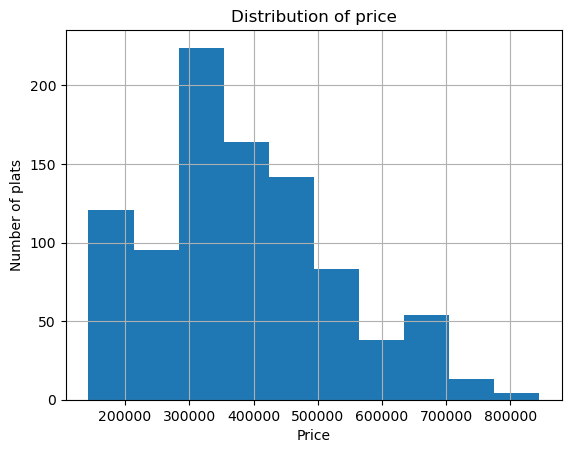

In [6]:
col_y = 'resale_price'

## Plot histogram
df[col_y].hist()
plt.title(f"Distribution of price")
plt.suptitle('')  # Remove default title by Pandas
plt.xlabel("Price")
plt.ylabel("Number of plats")
plt.show()

The histogram helsps visualize the distribution of target data more clearly. I analyze the distribution of the target variable to identify skewness and detect potential outliners before training the model

### 2.3.1.2 Understanding distribution of features

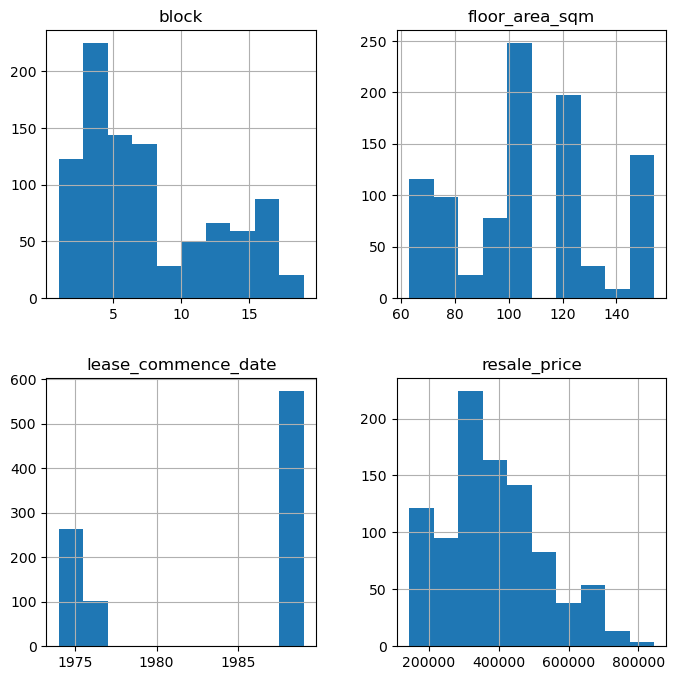

In [7]:
## Understanding distribution of features
df.hist(figsize=(8,8))
plt.show()

Visulaize the distribution of numerical features to identify data patterns, skewness, and potential outliers.<br>
For taget column (resale_price), it is slighly right-skewed, indicating that higher-priced houses are less common<br>
For floor_area_sqm, most properties fall within a moderate floor area range, while larger properties appear less frequently<br>
For less_commence_date, most houses were built during a few specific periods, suggestion an uneven distribution of construction years<br>

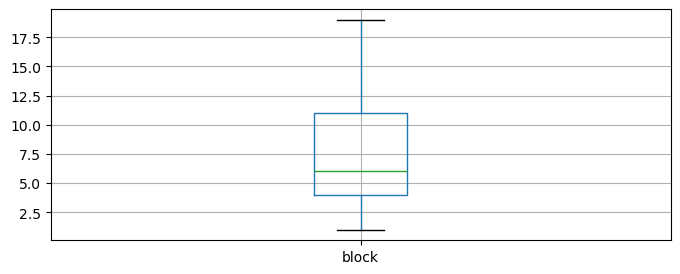

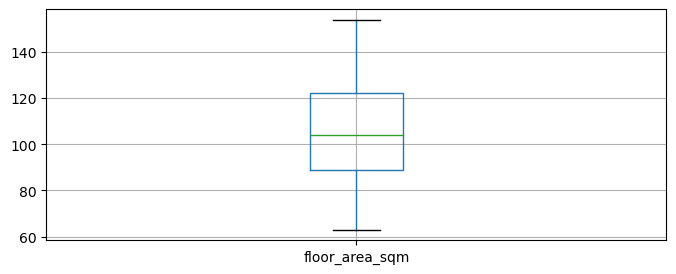

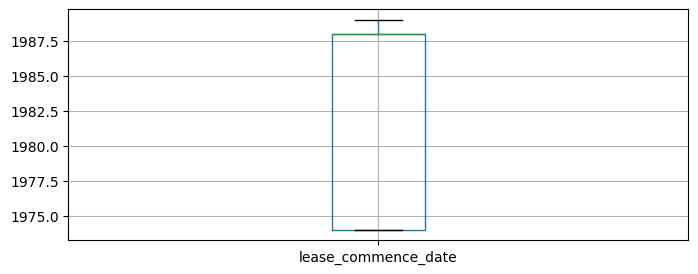

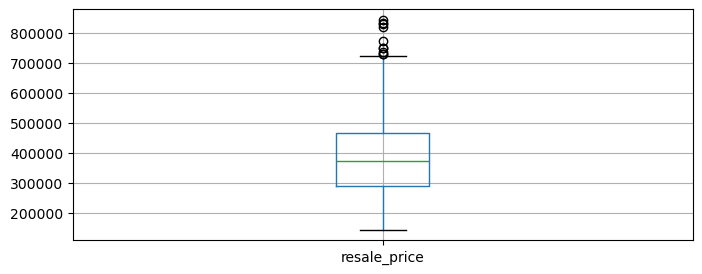

In [8]:
# analyze outliers

## retrieve numeric data columns
col_numeric = df.select_dtypes(include=['float', 'int']).columns ## Select all categorical columns

for col in col_numeric:
    df.boxplot(column=col, rot=0, figsize=(8,3))
    plt.show()

I create box plot for each of column. Because their values span a wild value range, most of boxes were unable to expand and it is hard to analyze if they were put into the same plot.<br>
The "block", "floor_area_sqm" and "lease_commence_date" show no obvious outliers. Their values fall within an reasonable range, indicating no additional outlier treatement is required<br>
However, the box plot for "resale_price" contains several high-value outliers, they are retained because they likely represent valid property prices rather than incorrect data<br>

### 2.3.2 Understanding relationship between variables

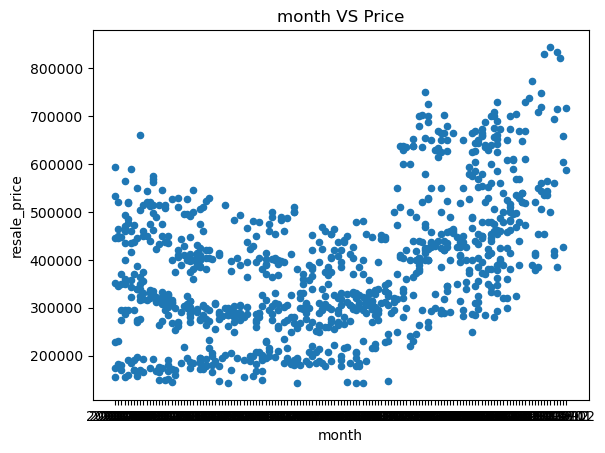

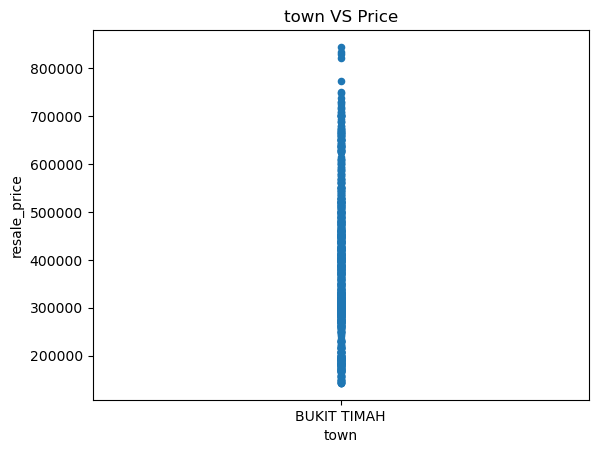

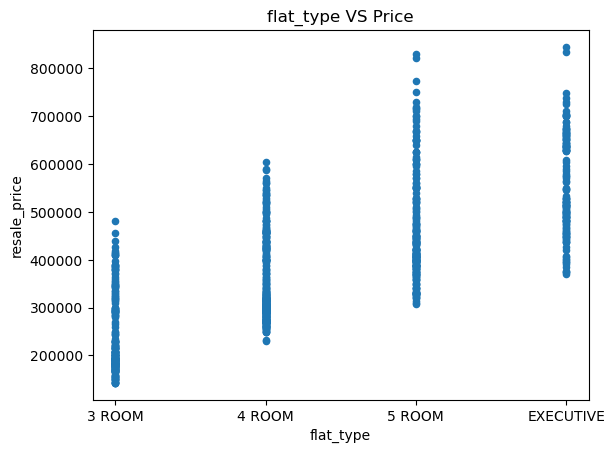

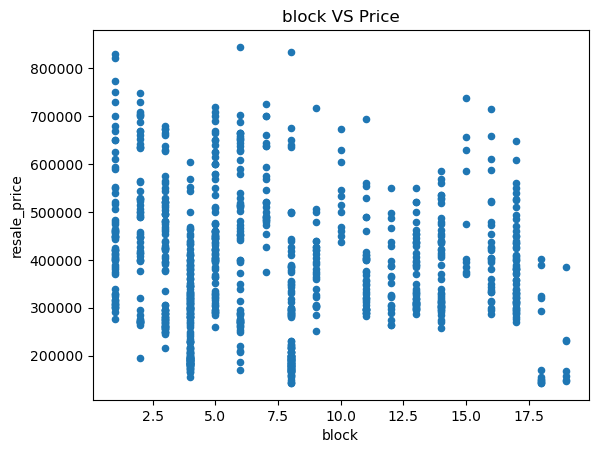

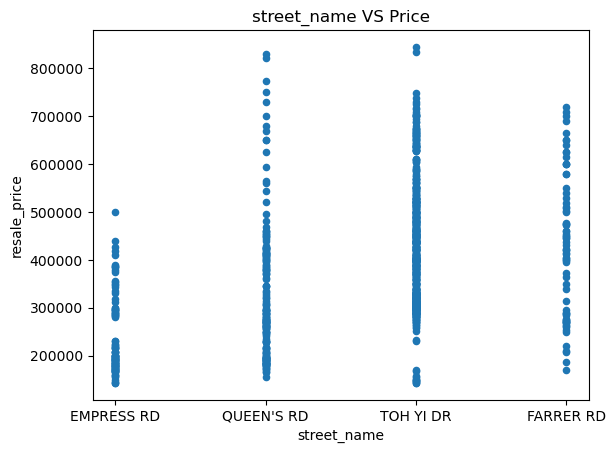

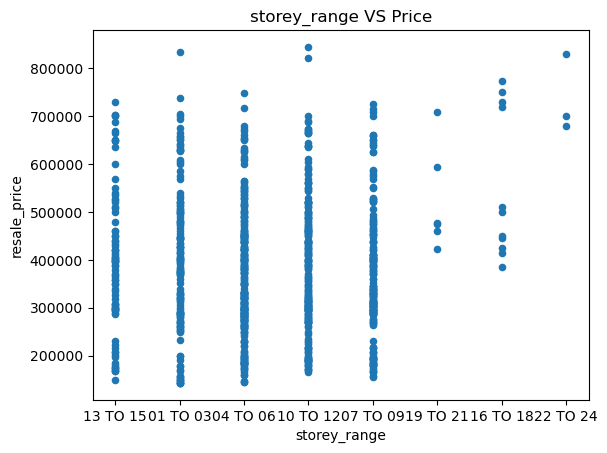

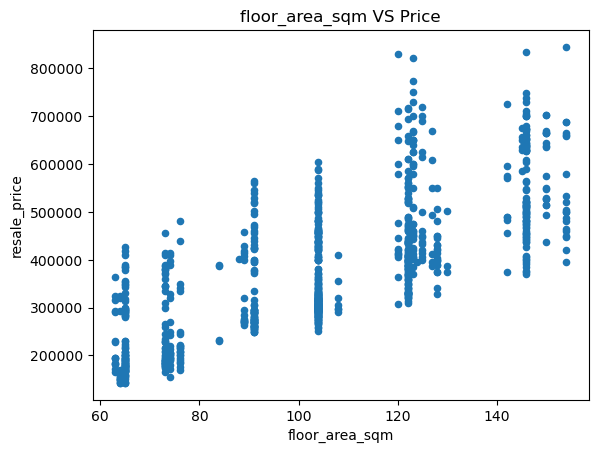

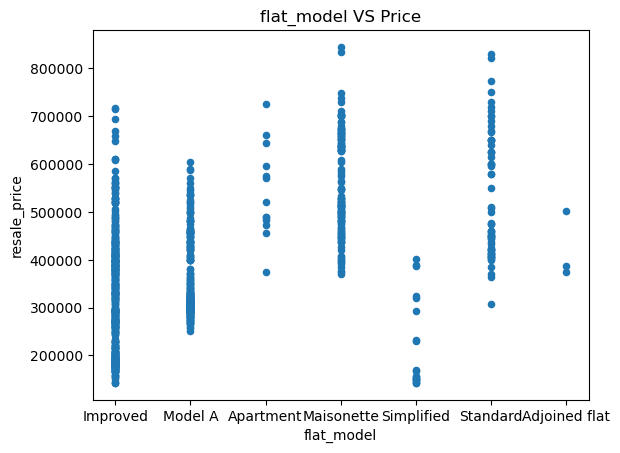

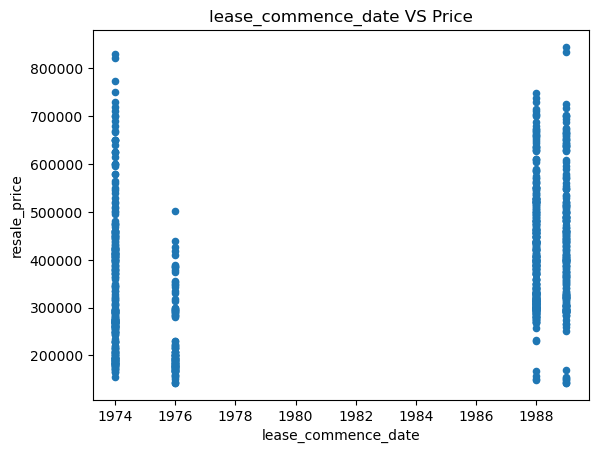

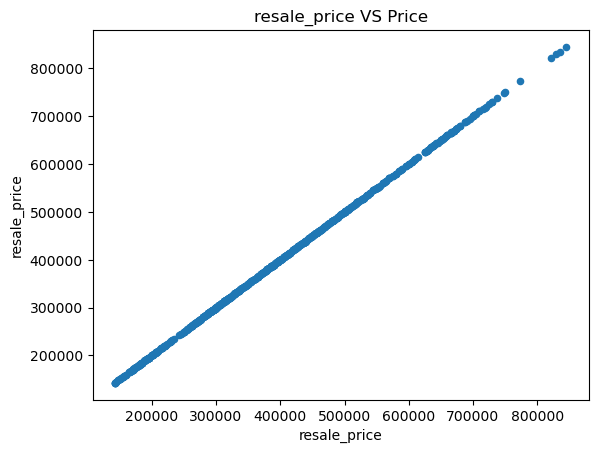

In [9]:
## Understanding relationship between variables
## Plot scatterplot
col_y = 'resale_price'

for col_x in df.columns:
    df.plot(x=col_x,
            y=col_y,
            kind='scatter')
    plt.title(f"{col_x} VS Price")
    plt.suptitle('')  # Remove default title by Pandas
    plt.xlabel(col_x)
    plt.ylabel(col_y)
    plt.show()

According to scatter plot shows:<br><br>
Town: Since all data were collected from the same town, the findings have limited research value. Thus, I will drop and clean the feature before next step<br><br>
["block" & "street name" & "storet range" & "lease_commence_date"] : these features contains multiple. Even though they do not show strong correlation with the target value, I will keep them and explore further to decide whether I keep them<br><br>
Rest of columns:  the remaining columns shows a certain level of positive correlation with the target value

In [10]:
df = df.drop("town", axis=1)

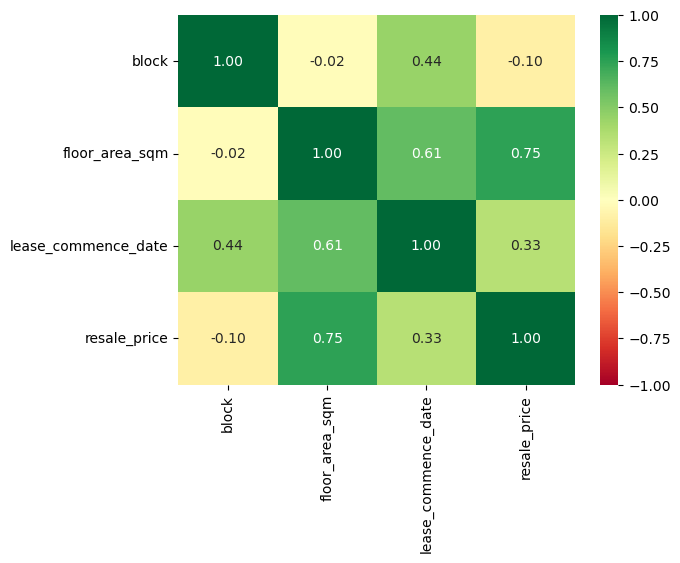

In [39]:
## Plot heatmap
## Display correlation matrix
df_corr = df[col_numeric].corr()
sns.heatmap(df_corr, 
            cmap='RdYlGn',
            annot=True,
            fmt=".2f",
            vmin=-1,vmax=1
)
plt.show()

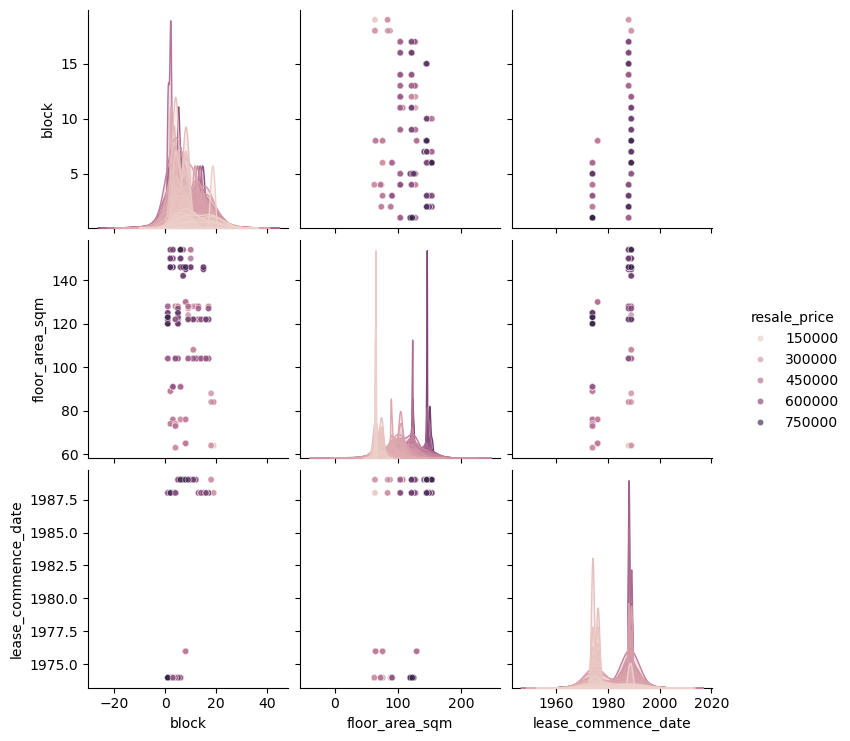

In [12]:
## Plot pairplot
sns.pairplot(df, 
             hue=col_y, # the dots should indicate different target value
             plot_kws={
                 "s":20, # smaller dots size is easier to show the distribution of dots
                 "alpha":0.7}) # appropriate opacity is helpful to check the distribution
plt.show()

According to heatmap : we can know that floor_area_sqm(feature) keeps high correlation with resale_price(target). Block(feature) has the weakest correlation with target value. lease_commence_date(feature) also has low correlation with target value. But I will still keep them and observe their performance<br><br>
Accordint to scatterplot matrix :<br>
[block vs floor_area_sqm] : as the floor_area_sqm increase, the color of resale_price(dots) become darker. That means the resale_price is increasing. However, dots' color dose not be affect significantly when block value changed, indicating that block is not the important feature to affect target value<br>
[block vs lease_commence_date] & [floor_area_sqm vs lease_commence_sqm] : Since most of lease_commence_date values in data are concentrated between 1989-1974 while the plot range of the feature is quite large. That makes data points appear highly clustered in the plot. Therefore, we keep lease_commence_date in model training and make decision according to model performance<br><br>
All in all, I will drop "block" column when I do OHE

# 3. Data Preparation

## 3.1 Data Cleaning

In [13]:
## Check datatypes for each column
df.dtypes

month                  object
flat_type              object
block                   int64
street_name            object
storey_range           object
floor_area_sqm          int64
flat_model             object
lease_commence_date     int64
resale_price            int64
dtype: object

In [14]:
## Check datatypes for each column
col_categorical = df.select_dtypes(include=['object']).columns ## Select all categorical columns

## Print data about categorical column
'''
nunique(): Return total number of unique values in column
unique(): Return unique values in column
'''
for col in df[col_categorical]:
    print(f'{col} ({df[col].nunique()}): {df[col].unique()}') 

month (145): ['2000-01' '2000-02' '2000-03' '2000-04' '2000-05' '2000-06' '2000-07'
 '2000-08' '2000-09' '2000-10' '2000-11' '2000-12' '2001-01' '2001-02'
 '2001-03' '2001-04' '2001-05' '2001-06' '2001-07' '2001-08' '2001-09'
 '2001-10' '2001-11' '2001-12' '2002-01' '2002-02' '2002-03' '2002-04'
 '2002-05' '2002-06' '2002-07' '2002-08' '2002-09' '2002-10' '2002-11'
 '2002-12' '2003-01' '2003-02' '2003-03' '2003-04' '2003-05' '2003-06'
 '2003-07' '2003-08' '2003-09' '2003-10' '2003-11' '2003-12' '2004-01'
 '2004-02' '2004-03' '2004-04' '2004-05' '2004-06' '2004-07' '2004-08'
 '2004-09' '2004-10' '2004-11' '2004-12' '2005-01' '2005-02' '2005-03'
 '2005-04' '2005-05' '2005-06' '2005-07' '2005-08' '2005-09' '2005-10'
 '2005-11' '2005-12' '2006-01' '2006-02' '2006-03' '2006-04' '2006-05'
 '2006-06' '2006-07' '2006-08' '2006-09' '2006-10' '2006-11' '2006-12'
 '2007-01' '2007-02' '2007-03' '2007-04' '2007-05' '2007-06' '2007-07'
 '2007-08' '2007-09' '2007-10' '2007-11' '2007-12' '2008-01' '20

## 3.2 One hot Encode (OHE)

In [15]:
## Split data into features (X) and target (y)
col_y = "resale_price" # target column
y = df[col_y] ## Select target column 

col_irrelevant = [col_y, 'block'] # drop out target column since One-hot-Encode only used for convert category in features into numeric value

X = df.drop(col_irrelevant, axis=1) ## Select feature columns 

## One-Hot Encoding
X = pd.get_dummies(X, 
               drop_first=True ## Remove redundant information
               )
X

,floor_area_sqm,lease_commence_date,month_2000-02,month_2000-03,month_2000-04,month_2000-05,month_2000-06,month_2000-07,month_2000-08,month_2000-09,...,storey_range_13 TO 15,storey_range_16 TO 18,storey_range_19 TO 21,storey_range_22 TO 24,flat_model_Apartment,flat_model_Improved,flat_model_Maisonette,flat_model_Model A,flat_model_Simplified,flat_model_Standard
0,76,1976,False,False,False,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
1,74,1974,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2,73,1974,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,104,1989,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,128,1989,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
933,65,1976,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
934,104,1988,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
935,122,1988,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
936,104,1988,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


Apply One-hot-Encode (OHE) because machine cannot recognize category values. Thus, we convert string into sevreal binary columns, making them suitable for machine learning models

## 3.3 Train-Test Split (TTS)

In [16]:
## Split data into train set and test set
from sklearn.model_selection import train_test_split

## Split data into train set and test set
test_size = 0.3  # 30% test data / 70% training data
random_state = 2026 ## For reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=test_size, 
                                                    random_state=random_state)

The data is split into a training set and a test set so the model can be evaluated on rows it has never seen. Scoring on the training data alone would be misleading because model can memorise thoes rows and overfit data<br><br>
Choose 7/3 -- training/test because dataset only 938 records in total. I split 70% of data that meet the training needs, while still leaving a small part of data for test so taht the test score is based on enoug flats to be resonably stable.<br><br>
The random_state is used to control the randomness of the data splitting process. It ensures that the split between training and testing datasets is reproducible. Without setting a random_state, the split will vary each time the code is executed, leading to different results.

# 4. Modelling

### 4.2 Train Model

In [17]:
## Initialise and train model
from sklearn.linear_model import LinearRegression
## Initialise model
model_linr = LinearRegression(fit_intercept=True) ## Linear Regression model
model_linr.fit(X_train, y_train) ## Train model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
## Initialise and train Random Forest model
from sklearn.ensemble import RandomForestRegressor
## Initialise model
model_rdn = RandomForestRegressor(random_state=random_state) ## Random Forest Regression model
model_rdn.fit(X_train, y_train) # Train Randem Forest Tree model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [19]:
## Initialise and train GradientBoosting model
from sklearn.ensemble import GradientBoostingRegressor
## Initialise model
model_gb = GradientBoostingRegressor(random_state=random_state) ## GradientBoosting model
model_gb.fit(X_train, y_train) # Train GradientBoosting model

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

# 5. Model Evaluation

As this is a regression problem, the target "resale_price" is a continous number, not a category. So classification metrics such as accuracy or F1 do not suitable for it. Amng regression metrics, the realistic choices are MAE, MSE and RMSE<br><br>
Why not MAE:<br>
MAE treates every dollar of error equally, so a model that is usually close but occasionally very wrong scores the same as a model that is consistently slightly off. That does not match this business. The EDA shows prices span S$143000 to S$845000 which means the prices are a very large value. Since MAE does not penalize large errors as heavily as MSE or RMSE, it may overlook significant prediction errors, resulting in a model that appear to perform well despite producing large deviations from the actual values.<br>
Why RMSE rather than MSE: <br>
Both of them are more sensitive than MAE, which means they could reflect prediction errors more accurate. However, prices are a very large value, MSE with high error sensitivity may overemphasize large errors due to the squaring operation and mislead evaluation of the model. One more important reason is MSE is measured in squared dollard, which means nothing to a buyer or an investor, while RMSE is in dollars and can be stated plainly.<br><br>
Why R² is reported as well:<br>
Since RMSE just tells me how many dollard the model is off by, but it does not tell me whether the model is good or bad. But R² helps here because it shows how much of the price difference between flats my features are able to explain. If R² is close to 0, the model is no better than just guessing the price every time. If R² is close to 1, the model is perfect.<br><br>
Thus, I will use both RMSE and R² to evaluate models

In [20]:
## Evaluate model
from sklearn.metrics import root_mean_squared_error, r2_score

## Evaluate model
y_pred_linr = model_linr.predict(X_test) ## Prediction using Linear Regression model
print("Linear Regression RMSE: ", root_mean_squared_error(y_test, y_pred_linr)) ## Calculate RMSE of model
print("Linear Regression R²: ", r2_score(y_test, y_pred_linr)) ## Calculate R2 of model

Linear Regression RMSE:  43332.87082676315
Linear Regression R²:  0.9081683114326591


In [21]:
## Evaluate model
y_pred_rdn = model_rdn.predict(X_test) ## Prediction using Random Forest Regression model

print("Random Forest Regression RMSE: ", root_mean_squared_error(y_test, y_pred_rdn)) ## Calculate RMSE of model
print("Random Forest Regression R²: ", r2_score(y_test, y_pred_rdn)) ## Calculate R2 of model

Random Forest Regression RMSE:  83243.91266773977
Random Forest Regression R²:  0.6611069867013195


In [22]:
## Evaluate model
y_pred_gb = model_gb.predict(X_test) ## Prediction using GradientBoosting model

print("Gradient Boosting Regression RMSE: ", root_mean_squared_error(y_test, y_pred_gb)) ## Calculate RMSE of model
print("Gradient Boosting Regression R²: ", r2_score(y_test, y_pred_gb)) ## Calculate R2 of model

Gradient Boosting Regression RMSE:  73362.45301127384
Gradient Boosting Regression R²:  0.736788212655917


## 6.Iterative model development

### 6.1 Feature important plot

In [23]:
# Check the feature columns
print(X.columns.tolist())

['floor_area_sqm', 'lease_commence_date', 'month_2000-02', 'month_2000-03', 'month_2000-04', 'month_2000-05', 'month_2000-06', 'month_2000-07', 'month_2000-08', 'month_2000-09', 'month_2000-10', 'month_2000-11', 'month_2000-12', 'month_2001-01', 'month_2001-02', 'month_2001-03', 'month_2001-04', 'month_2001-05', 'month_2001-06', 'month_2001-07', 'month_2001-08', 'month_2001-09', 'month_2001-10', 'month_2001-11', 'month_2001-12', 'month_2002-01', 'month_2002-02', 'month_2002-03', 'month_2002-04', 'month_2002-05', 'month_2002-06', 'month_2002-07', 'month_2002-08', 'month_2002-09', 'month_2002-10', 'month_2002-11', 'month_2002-12', 'month_2003-01', 'month_2003-02', 'month_2003-03', 'month_2003-04', 'month_2003-05', 'month_2003-06', 'month_2003-07', 'month_2003-08', 'month_2003-09', 'month_2003-10', 'month_2003-11', 'month_2003-12', 'month_2004-01', 'month_2004-02', 'month_2004-03', 'month_2004-04', 'month_2004-05', 'month_2004-06', 'month_2004-07', 'month_2004-08', 'month_2004-09', 'month

I found out there are too many months which may violate the principle of Curse of Dimensionality (CoD), decreasing the accuracy of model performance. Thus, I will transfer month into years to avoid overfitting 

In [24]:
# Create a new dataset for development
df_improve = df.copy()
df_improve = df_improve.drop("block",axis=1) # Drop block column keeping the same status as evaluation step

df_improve["year"]=df_improve["month"].apply(lambda x: int(x.split('-')[0]))
df_improve = df_improve.drop("month",axis=1) # Drop months since we use year represents it

# drop month column
col_y = "resale_price"
col_irrelevant = [col_y]

X_imp = df_improve.drop(col_irrelevant, axis=1) ## Select feature columns 

## One-Hot Encoding
X_imp = pd.get_dummies(X_imp, 
               drop_first=True ## Remove redundant information
               )

print(X_imp.columns.tolist())

['floor_area_sqm', 'lease_commence_date', 'year', 'flat_type_4 ROOM', 'flat_type_5 ROOM', 'flat_type_EXECUTIVE', 'street_name_FARRER RD', "street_name_QUEEN'S RD", 'street_name_TOH YI DR', 'storey_range_04 TO 06', 'storey_range_07 TO 09', 'storey_range_10 TO 12', 'storey_range_13 TO 15', 'storey_range_16 TO 18', 'storey_range_19 TO 21', 'storey_range_22 TO 24', 'flat_model_Apartment', 'flat_model_Improved', 'flat_model_Maisonette', 'flat_model_Model A', 'flat_model_Simplified', 'flat_model_Standard']


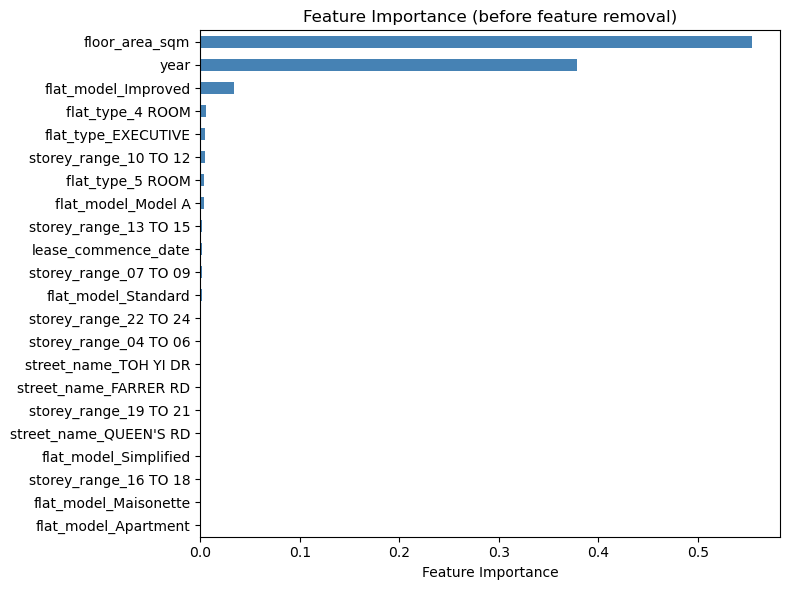

flat_model_Apartment      0.0000
flat_model_Maisonette     0.0002
storey_range_16 TO 18     0.0002
flat_model_Simplified     0.0002
street_name_QUEEN'S RD    0.0002
storey_range_19 TO 21     0.0002
street_name_FARRER RD     0.0003
street_name_TOH YI DR     0.0003
storey_range_04 TO 06     0.0003
storey_range_22 TO 24     0.0010
flat_model_Standard       0.0016
storey_range_07 TO 09     0.0016
lease_commence_date       0.0018
storey_range_13 TO 15     0.0018
flat_model_Model A        0.0037
flat_type_5 ROOM          0.0043
storey_range_10 TO 12     0.0043
flat_type_EXECUTIVE       0.0050
flat_type_4 ROOM          0.0055
flat_model_Improved       0.0342
year                      0.3786
floor_area_sqm            0.5548


In [25]:

gb_imp = GradientBoostingRegressor(random_state=2026)
gb_imp.fit(X_imp, y)         

importances = pd.Series(gb_imp.feature_importances_,
                        index=X_imp.columns).sort_values()

plt.figure(figsize=(8, 6))
importances.plot(kind="barh", color="steelblue")
plt.xlabel("Feature Importance")
plt.title("Feature Importance (before feature removal)")
plt.tight_layout()
plt.show()

print(importances.round(4).to_string())


The feature important plot shows that ""floor_area_sqm** and **year** are by far two most influential features, together making up most of model's total importance. Every other feature contributes very little.<br><br>
This matches real-world housing lofic:<br>
"floor_area_sqm" is the strongest driver because a larger flat almost always sells for more, so size directly explains most of price difference<br>
"year" is the second strongest because resale price rose steadily from 2000 to 2012, which is corelated with economy increasing and capture the overall market price trend<br><br>
Continuing with the Baseline model, there are two features stand out almost useless:<br>
"street_name": It is not a important feature in this case may because all data collect from the same town, and their locations are geographically close, location has a relatively limited impact on resale prices. The resale prices should differ in the size of flat built there, and "floor_area_sqm" tells the model directly<br>
"lease_commence_date": All flats were built with a narrow year age, so they are all a similar age. The feature cannot resonably reflect expensive flats or cheap flats<br>
Both of them contribute low importance for model<br><br>
The rest of unuseless features comes from One-Hot Encoding but I clarified the reason to keep them at last steps

### 6.2 Experiment of features' remove (street_name & lease_commence_date)

In [26]:
## The experiment of "street_name" droping

col_irrelevant_dropStreetName = [col_y, 'block',"street_name"]

X_dropStreetName = df.drop(col_irrelevant_dropStreetName, axis=1) ## Compare to baseline, droped street_name column

## One-Hot Encoding
X_dropStreetName = pd.get_dummies(X_dropStreetName, drop_first=True) ## Remove redundant information

## Split data into train set and test set
X_dropStreetName_train, X_dropStreetName_test, y_train, y_test = train_test_split(X_dropStreetName, 
                                                                                  y, 
                                                                                  test_size=test_size, 
                                                                                  random_state=random_state)

# Train models
model_linr_dropStreetName = LinearRegression(fit_intercept=True) ## Linear Regression model
model_linr_dropStreetName.fit(X_dropStreetName_train, y_train) ## Train model
model_rdn_dropStreetName = RandomForestRegressor(random_state=random_state) ## Random Forest Regression model
model_rdn_dropStreetName.fit(X_dropStreetName_train, y_train) # Train Randem Forest Tree model
model_gb_dropStreetName = GradientBoostingRegressor(random_state=random_state) ## GradientBoosting model
model_gb_dropStreetName.fit(X_dropStreetName_train, y_train) # Train GradientBoosting model

# Evaluate models
y_dropStreetName_pred_linr = model_linr_dropStreetName.predict(X_dropStreetName_test) ## Prediction using linr model
print("Linear Regression (Street Name moved) RMSE: ", root_mean_squared_error(y_test, y_dropStreetName_pred_linr)) ## Calculate RMSE of linr mode
print("Linear Regression (Street Name moved) R²: ", r2_score(y_test, y_dropStreetName_pred_linr)) ## Calculate R2 of linr mode
print()
y_dropStreetName_pred_rdn = model_rdn_dropStreetName.predict(X_dropStreetName_test) ## Prediction using rdn model
print("Random Forest Regression (Street Name moved) RMSE: ", root_mean_squared_error(y_test, y_dropStreetName_pred_rdn)) ## Calculate RMSE of rdn model
print("Random Forest Regression (Street Name moved) R²: ", r2_score(y_test, y_dropStreetName_pred_rdn)) ## Calculate R2 of rdn model
print()
y_dropStreetName_pred_gb = model_gb_dropStreetName.predict(X_dropStreetName_test) ## Prediction using gb model
print("Gradient Boosting Regression (Street Name moved) RMSE: ", root_mean_squared_error(y_test, y_dropStreetName_pred_gb)) ## Calculate RMSE of gb model
print("Gradient Boosting Regression (Street Name moved) R²: ", r2_score(y_test, y_dropStreetName_pred_gb)) ## Calculate R2 of gb model

Linear Regression (Street Name moved) RMSE:  43259.31348441358
Linear Regression (Street Name moved) R²:  0.9084798145306385

Random Forest Regression (Street Name moved) RMSE:  81521.93189239183
Random Forest Regression (Street Name moved) R²:  0.674982630193018

Gradient Boosting Regression (Street Name moved) RMSE:  73351.39824146536
Gradient Boosting Regression (Street Name moved) R²:  0.7368675318817628


In [27]:
## The experiment of "lease_commence_date" droping

col_irrelevant_dropLeaseCommenceDate = [col_y, 'block',"lease_commence_date"]

X_dropLeaseCommenceDate = df.drop(col_irrelevant_dropLeaseCommenceDate, axis=1) ## Compare to baseline, droped lease_commence_date column 

## One-Hot Encoding
X_dropLeaseCommenceDate = pd.get_dummies(X_dropLeaseCommenceDate, drop_first=True) ## Remove redundant information

## Split data into train set and test set
X_dropLeaseCommenceDate_train, X_dropLeaseCommenceDate_test, y_train, y_test = train_test_split(X_dropLeaseCommenceDate, 
                                                                                  y, 
                                                                                  test_size=test_size, 
                                                                                  random_state=random_state)

# Train model
model_linr_dropLeaseCommenceDate = LinearRegression(fit_intercept=True) ## Linear Regression model
model_linr_dropLeaseCommenceDate.fit(X_dropLeaseCommenceDate_train, y_train) ## Train model
model_rdn_dropLeaseCommenceDate = RandomForestRegressor(random_state=random_state) ## Random Forest Regression model
model_rdn_dropLeaseCommenceDate.fit(X_dropLeaseCommenceDate_train, y_train) # Train Randem Forest Tree model
model_gb_dropLeaseCommenceDate = GradientBoostingRegressor(random_state=random_state) ## GradientBoosting model
model_gb_dropLeaseCommenceDate.fit(X_dropLeaseCommenceDate_train, y_train) # Train GradientBoosting model

# Evaluate model
y_dropLeaseCommenceDate_pred_linr = model_linr_dropLeaseCommenceDate.predict(X_dropLeaseCommenceDate_test) ## Prediction using linr model
print("Linear Regression (Lease_commence_date moved) RMSE: ", root_mean_squared_error(y_test, y_dropLeaseCommenceDate_pred_linr)) ## Calculate RMSE of linr model
print("Linear Regression R²: ", r2_score(y_test, y_dropLeaseCommenceDate_pred_linr)) ## Calculate R2 of linr model
print()
y_dropLeaseCommenceDate_pred_rdn = model_rdn_dropLeaseCommenceDate.predict(X_dropLeaseCommenceDate_test) ## Prediction using rdn model
print("Random Forest Regression (Lease_commence_date moved) RMSE: ", root_mean_squared_error(y_test, y_dropLeaseCommenceDate_pred_rdn)) ## Calculate RMSE of rdn model
print("Random Forest Regression (Lease_commence_date moved) R²: ", r2_score(y_test, y_dropLeaseCommenceDate_pred_rdn)) ## Calculate R2 of rdn model
print()
y_dropLeaseCommenceDate_pred_gb = model_gb_dropLeaseCommenceDate.predict(X_dropLeaseCommenceDate_test) ## Prediction using gb model
print("Gradient Boosting Regression (Lease_commence_date moved) RMSE: ", root_mean_squared_error(y_test, y_dropLeaseCommenceDate_pred_gb)) ## Calculate RMSE of gb model
print("Gradient Boosting Regression (Lease_commence_date moved) R²: ", r2_score(y_test, y_dropLeaseCommenceDate_pred_gb)) ## Calculate R2 of gb model


Linear Regression (Lease_commence_date moved) RMSE:  43324.1515994765
Linear Regression R²:  0.908205263556664

Random Forest Regression (Lease_commence_date moved) RMSE:  82749.069855531
Random Forest Regression (Lease_commence_date moved) R²:  0.6651241051749044

Gradient Boosting Regression (Lease_commence_date moved) RMSE:  73373.79163465936
Gradient Boosting Regression (Lease_commence_date moved) R²:  0.73670684433089


<table>
    <tr>
        <th><br>Model</br></th>
        <th><br>Baseline</br></th>
        <th><br>Remove street_name</br></th>
        <th><br>Remove lease_commence_date</br></th>
    </tr>
    <tr>
        <td>Linear Regression R²</td>
        <td>0.9081683114326591</td>
        <td>0.9084798145306385</td>
        <td>0.908205263556664</td>
    </tr>
    <tr>
        <td>Random Forest R²</td>
        <td>0.6611069867013195</td>
        <td>0.674982630193018</td>
        <td>0.6651241051749044</td>
    </tr>
    <tr>
        <td>Gradient Boosting R²</td>
        <td>0.736788212655917</td>
        <td>0.7368675318817628</td>
        <td>0.73670684433089</td>
    </tr>
</table>

<table>
    <tr>
        <th><br>Model</br></th>
        <th><br>Baseline</br></th>
        <th><br>Remove street_name</br></th>
        <th><br>Remove lease_commence_date</br></th>
    </tr>
    <tr>
        <td>Linear Regression RMSE</td>
        <td>43332.87082676315</td>
        <td>43259.31348441358</td>
        <td>43324.1515994765</td>
    </tr>
    <tr>
        <td>Random Forest RMSE</td>
        <td>83243.91266773977</td>
        <td>81521.93189239183</td>
        <td>82749.069855531</td>
    </tr>
    <tr>
        <td>Gradient Boosting RMSE</td>
        <td>73362.45301127384</td>
        <td>73351.39824146536</td>
        <td>73373.79163465936</td>
    </tr>
</table>

Above tables shows the compare of removing uncertain features to explore the impact to models' performance.<br><br>
Based on the table result and feature important plot, both  features (street_name & lease_commene_date) should be noisy data. Since their removal has little impact on all three models' performance and their accuracy almost stay the same and feature important plot indicates low contribution<br>
In conclusion, I deicde to drop both street_name & lease_commence_date.<br><br>
Overall, all uncertain features have been identified and decide to remove, leaving only the important and informative features that contribute meaningfully to the model's predictive performance

### 6.3 Related features grouping

In [28]:
noisy_features = ['street_name',
                  "lease_commence_date"]
df_improve = df_improve.drop(noisy_features, axis=1)  # remove all noisy features

df_improve["storey_mid"] = df_improve["storey_range"].apply(lambda X: (int(X.split("TO")[0]) + int(X.split("TO")[1])) / 2)
# convert string value into median numeric value, since median serves as a representative value for the entire interval while preseving the relative floor level information.

df_improve[["storey_range","storey_mid"]].head(10) # double check the transform result

,storey_range,storey_mid
0,13 TO 15,14.0
1,01 TO 03,2.0
2,04 TO 06,5.0
3,01 TO 03,2.0
4,04 TO 06,5.0
5,10 TO 12,11.0
6,01 TO 03,2.0
7,04 TO 06,5.0
8,07 TO 09,8.0
9,04 TO 06,5.0


Compare with using floor area alone, clustering by both floor area and storey range provides a more informative representation of the properties. Instead of considering only property size, the data are grouped into meaningful categories, such as large units on higher floors, small units on higher floors, large units on lower floors, and small units on lower floors. This richer representation allows the model to identify more specific pricing patterns and provides more relavent reference groups for price prediction.<br><br>
From a pratical perspective, storey range is also an important factor considered by home buyers. Higher-floor units are often preferred because of factors such as better views, improved ventilation, less prone to moisture, and reduce noise, which may indirectly influence resale prices. Therefore, combining floor area with storey range is likely to improve models' ability to capture real-world housing preferences and enhance prediction performance.<br><br>
However, since values in storey_range are strings, I need to convert string values into meaningful numeric values that accurately represent their underlying information. Then cluster with floor_area_sqm

c:\Users\yongc\anaconda3\envs\mldp\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\yongc\anaconda3\envs\mldp\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\yongc\anaconda3\envs\mldp\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\yongc\anaconda3\envs\mldp\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans 

<function matplotlib.pyplot.show(close=None, block=None)>

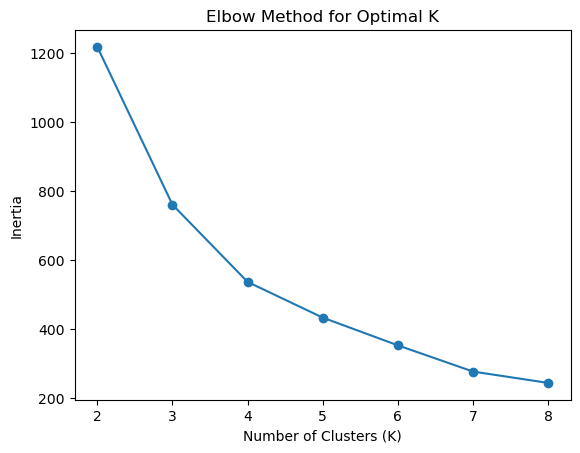

In [29]:
# select cluster value K by Elbow
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# select features for clustering
cluster_features = df_improve[["storey_mid","floor_area_sqm"]]

# Initialize their value range
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_features)

# Elbow Method
inertia = []
K_range = range(2,9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    km.fit(cluster_scaled)
    inertia.append(km.inertia_)

plt.plot(K_range, inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show

K-Means clustering is used to identify groups of properties with similar chravteristics. Thus, I apply K-Means before clustering to help me find out the best K value which stands for group numbers. Because clustering with best K value is helpful for machine to learn data and performance well

In [30]:
# Sillhouette Score verification
from sklearn.metrics import silhouette_score

for k in K_range:
    km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    labels = km.fit_predict(cluster_scaled)
    score = silhouette_score(cluster_scaled, labels)
    print(f"K={k}, Silhouette Score={score:.4f}")

c:\Users\yongc\anaconda3\envs\mldp\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\yongc\anaconda3\envs\mldp\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\yongc\anaconda3\envs\mldp\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


K=2, Silhouette Score=0.3490
K=3, Silhouette Score=0.3849
K=4, Silhouette Score=0.4144


c:\Users\yongc\anaconda3\envs\mldp\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\yongc\anaconda3\envs\mldp\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\yongc\anaconda3\envs\mldp\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


K=5, Silhouette Score=0.4189
K=6, Silhouette Score=0.4508
K=7, Silhouette Score=0.4604
K=8, Silhouette Score=0.4767


c:\Users\yongc\anaconda3\envs\mldp\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


Double check K=3 or K=4, which one is better. 

I will choose K=4 according to Elbow and Sihouette Score. Although 8 is the highest value, we need to consider both Elbow and Sihouette Score to determine the value of K.<br>
According to Elbow, the slope decrease significantly when k=4, indicating the cluster number decrease the contribution for inertia after k=4<br>
According to Silhouette Score, Although k=8 has the highest value, it inceases slightly. More importantly, the cluster numbers increase significantly which may increase the complexity of model and cause overfitting

In [31]:
best_k = 4

km_final = KMeans(n_clusters=best_k, random_state=random_state, n_init=10)
df_improve["storey_area_cluster"]=km_final.fit_predict(cluster_scaled)

# Examine the characteristics of each cluster
df_improve.groupby("storey_area_cluster")[["storey_mid", "floor_area_sqm", "resale_price"]].mean()

c:\Users\yongc\anaconda3\envs\mldp\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


,storey_mid,floor_area_sqm,resale_price
storey_area_cluster,,,
0,4.961864,133.631356,484462.983051
1,5.009119,91.680851,314452.814590
2,10.546053,72.407895,260335.131579
3,12.574661,121.022624,466393.556561


From the result, we can know that the data was clearly divided into four distinct groups : large units on higher floors (cluster3), small units on higher floors (cluster2), large units on lower floors (cluster0), and small units on lower floors (cluster1), making the data easier to analyze and interpret

In [32]:
## Split data into features (X) and target (y)
col_y = "resale_price"
y = df_improve[col_y] ## Select target column 

df_improve["storey_area_cluster"] = df_improve["storey_area_cluster"].astype(str)
# convert the cluster number into string values for OHE since Linear Regression assumes numerical features have a meaningful quantitative relationship with the target. But the numner just for distinguishing different types

col_irrelevant = [col_y,
                  'storey_range']  # drop out storey_range since I have already use storey_mid to represent it

X_improve = df_improve.drop(col_irrelevant, axis=1) ## Select feature columns

## One-Hot Encoding
X_improve = pd.get_dummies(X_improve, 
               drop_first=True ## Remove redundant information
               )


print(X_improve.columns.tolist())

['floor_area_sqm', 'year', 'storey_mid', 'flat_type_4 ROOM', 'flat_type_5 ROOM', 'flat_type_EXECUTIVE', 'flat_model_Apartment', 'flat_model_Improved', 'flat_model_Maisonette', 'flat_model_Model A', 'flat_model_Simplified', 'flat_model_Standard', 'storey_area_cluster_1', 'storey_area_cluster_2', 'storey_area_cluster_3']


### 6.4 Best model selection

In [33]:
## Split data into train set and test set
from sklearn.model_selection import train_test_split

## Split data into train set and test set
test_size = 0.3 
random_state = 2026 ## For reproducibility
X_improve_train, X_improve_test, y_train, y_test = train_test_split(X_improve, 
                                                    y, 
                                                    test_size=test_size, 
                                                    random_state=random_state)


## Initialise and train model
from sklearn.linear_model import LinearRegression
## Initialise model
model_linr_clustered = LinearRegression(fit_intercept=True) ## Linear Regression model
model_linr_clustered.fit(X_improve_train, y_train) ## Train model

## Initialise and train Random Forest model
from sklearn.ensemble import RandomForestRegressor
## Initialise model
model_rdn_clustered = RandomForestRegressor(random_state=random_state) ## Random Forest Regression model
model_rdn_clustered.fit(X_improve_train, y_train) # Train Randem Forest Tree model

## Initialise and train GradientBoosting model
from sklearn.ensemble import GradientBoostingRegressor
## Initialise model
model_gb_clustered = GradientBoostingRegressor(random_state=random_state) ## GradientBoosting model
model_gb_clustered.fit(X_improve_train, y_train) # Train GradientBoosting model

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [34]:
## Evaluate clustered linear model
y_pred_linr_clustered = model_linr_clustered.predict(X_improve_test) ## Prediction using Linear Regression model
print("Clustered Linear Regression RMSE: ", root_mean_squared_error(y_test, y_pred_linr_clustered)) ## Calculate RMSE of Linear Regression model
print("Clustered Linear Regression R²: ", r2_score(y_test, y_pred_linr_clustered)) ## Calculate R2 of Linear Regression model
print()

## Evaluate clustered random forest tree model
y_pred_rdn_clustered = model_rdn_clustered.predict(X_improve_test) ## Prediction using Random Forest Regression model
print("Clustered Random Forest Regression RMSE: ", root_mean_squared_error(y_test, y_pred_rdn_clustered)) ## Calculate RMSE of Random Forest Regression model
print("Clustered Random Forest Regression R²: ", r2_score(y_test, y_pred_rdn_clustered)) ## Calculate R2 of Random Forest Regression model
print()

## Evaluate clustered gradientbossting model
y_pred_gb_clustered = model_gb_clustered.predict(X_improve_test) ## Prediction using GradientBoosting model
print("Clustered Gradient Boosting Regression RMSE: ", root_mean_squared_error(y_test, y_pred_gb_clustered)) ## Calculate RMSE of GradientBoosting model
print("Clustered Gradient Boosting Regression R²: ", r2_score(y_test, y_pred_gb_clustered)) ## Calculate R2 of GradientBoosting model

Clustered Linear Regression RMSE:  62232.90559004723
Clustered Linear Regression R²:  0.8105922251699904

Clustered Random Forest Regression RMSE:  31746.02516106729
Clustered Random Forest Regression R²:  0.9507125490574218

Clustered Gradient Boosting Regression RMSE:  31069.562372526623
Clustered Gradient Boosting Regression R²:  0.9527906612159646


After applying feature engineering (storey_area clustering, storey_mid, and replacing month with year), both Random Forest and GradientBoosting showed significant improvement. And Gradient Boosting showed best performance with R² of 0.9528 and RMSE of 31073, a substantial improvement over its baseline R² of 0.7367<br>
Linear Regression performed worse after the changes because the 144 dummies (months) let Linear Regression fit the price trend piecewise, while a single linear "year" term cannot.<br><br>
Based on this comparison, GradientBoosting is selected as the best model for hyperparameter tuning, as it achieved the highest R² and lowest RMSE among all models

### 6.5 Hyperparameter tuning

In [38]:
# Random Search
from sklearn.model_selection import RandomizedSearchCV

# Hyperparameter tuning for Gradient Boosting
param_distributions = {
    'n_estimators': [100, 700, 800],
    'learning_rate': [0.005, 0.01, 0.1],
    'max_depth': [3,4,5]
}

model_gb_tuned = GradientBoostingRegressor(random_state=random_state)

random_search = RandomizedSearchCV(
    estimator = model_gb_tuned, 
    param_distributions = param_distributions,
    cv = 5, ## Number of cross-validation folds
    scoring = 'neg_root_mean_squared_error', ## Scoring metric
    n_iter = 27, ## Number of parameter settings sampled
    n_jobs = -1 ## -1: Use all available cores
    )

random_search.fit(X_improve_train, y_train)


print("Best Parameters: ", random_search.best_params_)
print("Best CV RMSE: ", random_search.best_score_)


Best Parameters:  {'n_estimators': 700, 'max_depth': 4, 'learning_rate': 0.01}
Best CV RMSE:  -31202.633684294706


In [36]:
# 
tuned_model = random_search.best_estimator_

y_pred_tuned = tuned_model.predict(X_improve_test)
print("Tuned GradientBoosting RMSE: ", root_mean_squared_error(y_test, y_pred_tuned)) ## Calculate RMSE of tuned GradientBoosting model
print("Tuned GradientBoosting R²: ", r2_score(y_test, y_pred_tuned)) ## Calculate R2 of tuned GradientBoosting model

Tuned GradientBoosting RMSE:  32225.004337605307
Tuned GradientBoosting R²:  0.949214046051211


<table>
    <tr>
        <th><br>Model</br></th>
        <th><br>GradientBoosting</br></th>
        <th><br>Tuned GradientBoosting</br></th>
    </tr>
    <tr>
        <td>RMSE</td>
        <td>31069.562372526623</td>
        <td>32225.004337605307</td>
    </tr>
    <tr>
        <td>R²</td>
        <td>0.9527906612159646</td>
        <td>0.949214046051211</td>
    </tr>
</table>

Based on the comparison of the performance before and after, I will choose the basic GradientBoosting model as the final model :<br>
1. The basic model performs better than tuning model no matter RMSE (smaller) or R² (closer to 1)
2. Although the two models achieved very similar R² values, the tuned model produced an RMSE that was nearly SGD 1200. In the real world, 1200 dollars are quite a large funds and it may influence buyer's purchasing decisions
3. Their n_estimator : 100 vs 700, which means the tuned one has a larger model size. It will take longer time than basic model when streamlit load model to predict on frontend

In [37]:
# Select the before tuning version as best model
best_model = model_gb_clustered

# Save model
import joblib
joblib.dump({
            "model": best_model,
            "scaler": scaler,
            "kmeans": km_final,
            "columns": X_improve.columns.tolist(),
}, "house_predict_best_model.pkl") ## Save the best model

['house_predict_best_model.pkl']

Finally, I will choose the GradientBoosting model (before tuning one) with final setting {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1} which is the defult setting of GradientBoosting model